# Quantum trajectories

Quantum trajectories are a powerful tool for simulating open quantum dynamics. The idea is simple: the Lindblad master equation
\begin{equation}
\partial_t \rho = -i[H,\rho] + \sum_m \gamma_m \left( L_m \rho L_m^\dagger - \frac{1}{2} \{L_m^\dagger L_m, \rho\}\right)
\end{equation}
generates a mixed state $\rho$, which can be thought as a statistical mixture of multiple pure states
\begin{equation}
\rho = \sum_j p_j |\psi_j\rangle\langle|\psi_j|.
\end{equation}
Instead of evaluating the dynamics of the density matrix, one can **unravel** the dynamics in a collection of stochastic pure quantum trajectories, and access ensemble-averaged properties as statistical averages.

The main advantage of this procedure is the reduction of the size of the state to be stored. For a Hilbert space of dimension $D$, pure states are arrays of $D$ elements, whereas density matrices contain $D^2$ elements.

We now illustrate some basic examples on how quantum trajectories can be used to simulate open-system evolution. Consider the Lindblad master equation characterized by a single-qubit Hamiltonian
\begin{equation}
H = \omega \sigma^x
\end{equation}
and a single jump operator
\begin{equation}
L = \sigma^+ = \frac{\sigma^x+i\sigma^y}{2},
\end{equation}
with a dissipation rate $\gamma$.

In [33]:
using LinearAlgebra
using QuantumToolbox
using CairoMakie

# Hamiltonian
X = [0 1; 1 0]
omega = 1.0
H = omega * X

# Jump operator
L = [0 1; 0 0]
gamma = 0.5;

We implement the **quantum jump** unraveling of the master equation.

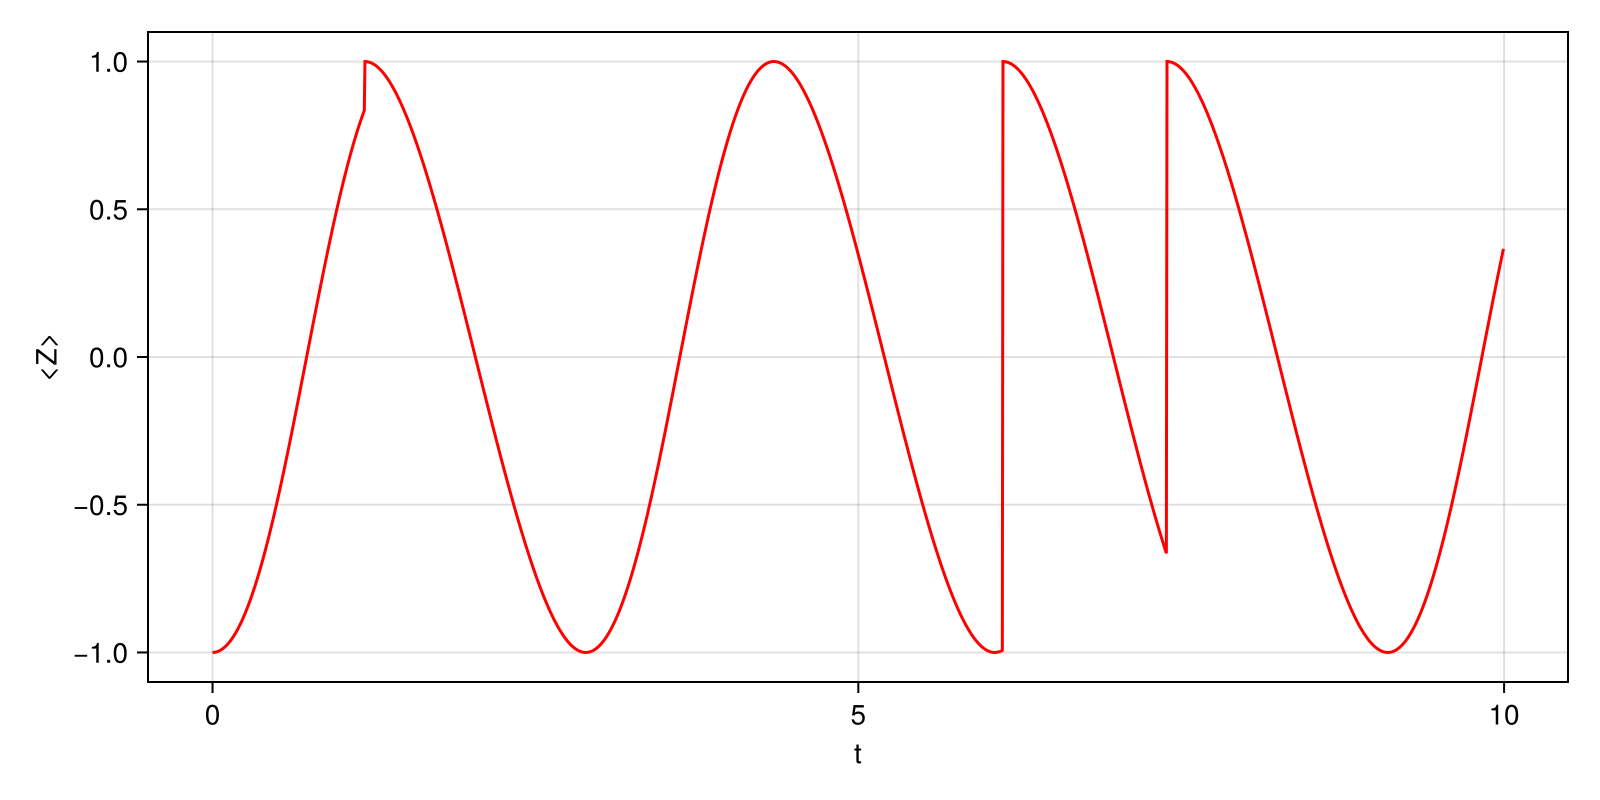

In [34]:
# Parameters

psi0 = [0, 1] # down state
dt = 0.005
ntsteps = 2000

# Effective Hamiltonian
Heff = H - 0.5im * gamma * L' * L

function jump_evolution(L, psi)
    # Perform a jump and renormalize the state
    psi_out = L * psi
    n = norm(psi_out)
    return psi_out/n
end

function quantum_jump_evolution(Heff, L, dt, ntsteps, psi0)
    # Implement quantum jump dynamics using the method of arXiv:1405.6694, Sec. III.D
    Z = [1 0; 0 -1]
    Z_avg = zeros(ntsteps)

    U = exp(-im * Heff * dt)
    # Since this is a single qubit, we could actually evaluate U exactly, but
    # it's not possible in general.

    r = rand()
    n = 1.0

    psi = copy(psi0)

    for tt in 1:ntsteps
        Z_avg[tt] = real(psi' * Z * psi) / n^2

        psi = U * psi
        # If we have a many-body system, usually it's not possible to build U.
        # We can instead integrate numerically the (effective) Schrodinger eq.

        n = norm(psi)

        if n^2 < r
            psi = jump_evolution(L, psi)
            n = 1.0
            r = rand()
        end
    end

    return Z_avg
end

Z_traj = quantum_jump_evolution(Heff, L, dt, ntsteps, psi0)

t = (0:ntsteps-1) .* dt

fig = Figure(size = (800, 400))
ax = Axis(fig[1, 1],
    xlabel = "t",
    ylabel = "<Z>",
    xgridvisible = true,
    ygridvisible = true
)

lines!(ax, t, Z_traj, color = :red, linewidth = 1.5)

fig

Single quantum-jump trajectories feature sudden discontinuities. Indeed, the operator $L$ implements instantaneous jumps in the Hilbert space.

Now, let's generate many trajectories and track the average magnetization.

In [35]:
sample = 5000

Z_qj = zeros(ntsteps)
Z2_qj = zeros(ntsteps)

for ss in 1:sample
    Z_traj = quantum_jump_evolution(Heff, L, dt, ntsteps, psi0)
    Z_qj .+= Z_traj ./ sample
    Z2_qj .+= (Z_traj .^ 2) ./ sample
end

sigma_Z_qj = sqrt.(Z2_qj .- Z_qj.^2 .+ 1e-10) ./ sqrt(sample);

Compare to the Lindblad evolution

[mesolve] 100%|███████████████████████████| Time: 0:00:00 ( 0.61 μs/it)


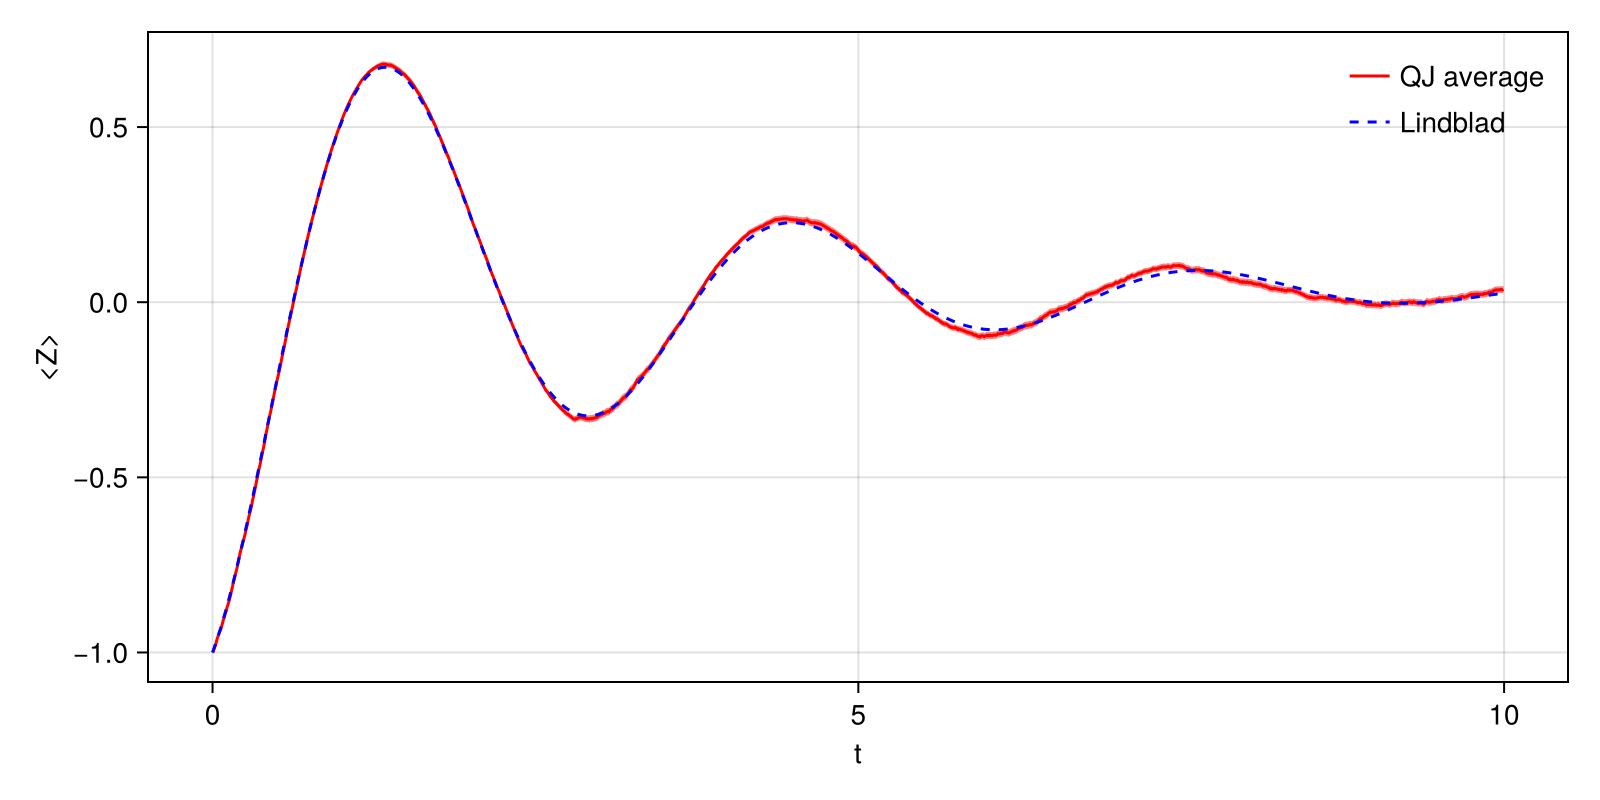

In [36]:
result = mesolve(omega*sigmax(), basis(2,1), t, [sqrt(gamma)*sigmap()]; e_ops=[sigmaz()])
Z_lind = real.(result.expect[1, :])

fig = Figure(size = (800, 400))
ax = Axis(fig[1, 1],
    xlabel = "t",
    ylabel = "<Z>",
    xgridvisible = true,
    ygridvisible = true
)

band!(ax, t, Z_qj .- sigma_Z_qj, Z_qj .+ sigma_Z_qj, color = (:red, 0.5))
lines!(ax, t, Z_qj, color = :red, label = "QJ average")
lines!(ax, t, Z_lind, color = :blue, linestyle = :dash, label = "Lindblad")
axislegend(ax, framevisible = false)

fig

Now, let's try with a different unraveling, the so-called **quantum state diffusion**. Quantum trajectories are defined by the update equation
\begin{equation}
d|\psi_t\rangle = d\xi_t (L-\langle L\rangle_t)|\psi_t\rangle - \frac{\gamma dt}{2}\left(L^\dagger L + \langle L\rangle_t^* \langle L\rangle_t - 2 \langle L\rangle_t^* L\right)|\psi_t\rangle,
\end{equation}
where $\langle L\rangle_t = \langle \psi_t|L|\psi_t\rangle_t$, and $d\xi_t$ is a classical stochastic process satisfying
\begin{equation}
\overline{d \xi_t}=0 \qquad \qquad \overline{d\xi_t d\xi^*_t} = \gamma dt.
\end{equation}
**Exercise:** prove that this unraveling gives rise to the same Lindblad master equation introduced before. Hint: write down the increment of the density matrix $d\rho_t$, and compute all terms up to $\mathcal{O}(dt)$, keeping in mind that $d\xi_t = \mathcal{O}(dt^{1/2})$.

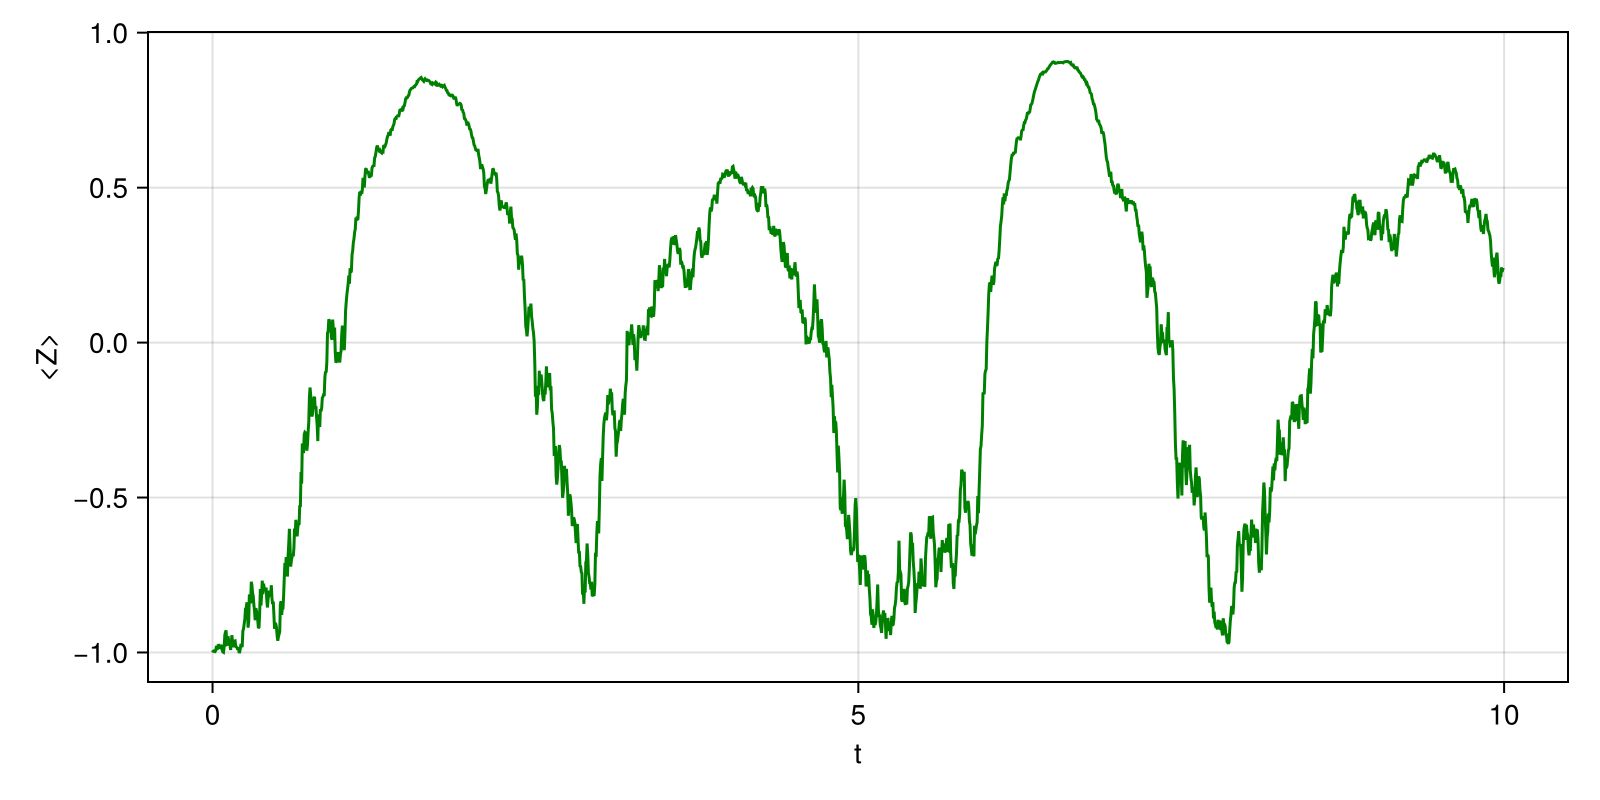

CairoMakie.Screen{IMAGE}


In [37]:
function quantum_state_diffusion(H, L, gamma, dt, ntsteps, psi0)
    # Implement quantum state diffusion
    Z = [1 0; 0 -1]
    Z_avg = zeros(ntsteps)

    LdagL = L'*L

    psi = copy(psi0)

    for tt in 1:ntsteps
        Z_avg[tt] = real(psi' * Z * psi)

        L_avg = psi' * L * psi

        dxi = sqrt(gamma * dt) * randn(ComplexF64)

        psi += -im * dt * H * psi +
               dxi * (L * psi - L_avg * psi) -
               0.5 * gamma * dt * (LdagL * psi + abs(L_avg)^2 * psi - 2 * conj(L_avg) * L * psi)

        # Renormalize: numerical approximation can lead to loss of normalization
        # Since we do this, we could have neglected constant terms in the update if wanted
        psi /= norm(psi)
    end

    return Z_avg
end

Z_traj = quantum_state_diffusion(H, L, gamma, dt, ntsteps, psi0)

# --- CairoMakie Plotting ---

fig = Figure(size = (800, 400))
ax = Axis(fig[1, 1],
    xlabel = "t",
    ylabel = "<Z>",
    xgridvisible = true,
    ygridvisible = true
)

lines!(ax, t, Z_traj, color = :green)

display(fig)

Notice how the trajectory looks rather different from the quantum jump unraveling. In fact, now there is no discontinuous update of the state, but rather a diffusive stochastic contribution to the equation of motion.

Let's take the ensemble average and compare to the previous results.

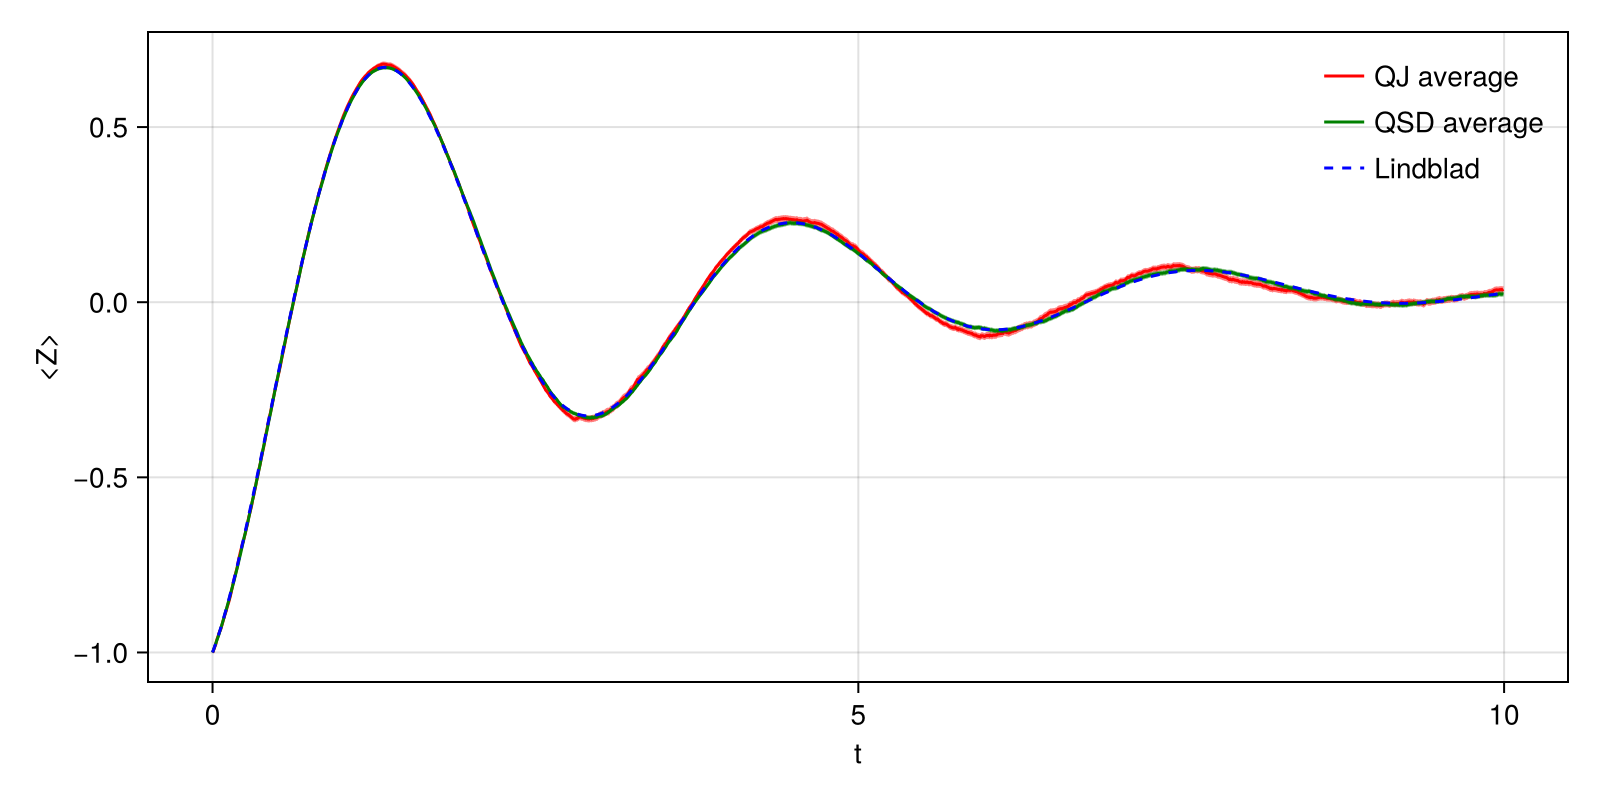

In [38]:
Z_qsd = zeros(ntsteps)
Z2_qsd = zeros(ntsteps)

for ss in 1:sample
    Z_traj = quantum_state_diffusion(H, L, gamma, dt, ntsteps, psi0)
    Z_qsd .+= Z_traj ./ sample
    Z2_qsd .+= (Z_traj .^ 2) ./ sample
end

sigma_Z_qsd = sqrt.(Z2_qsd .- Z_qsd.^2 .+ 1e-10) ./ sqrt(sample)

fig = Figure(size = (800, 400))
ax = Axis(fig[1, 1],
    xlabel = "t",
    ylabel = "<Z>",
    xgridvisible = true,
    ygridvisible = true
)

band!(ax, t, Z_qj .- sigma_Z_qj, Z_qj .+ sigma_Z_qj, color = (:red, 0.5))
lines!(ax, t, Z_qj, color = :red, label = "QJ average")
band!(ax, t, Z_qsd .- sigma_Z_qsd, Z_qsd .+ sigma_Z_qsd, color = (:green, 0.5))
lines!(ax, t, Z_qsd, color = :green, label = "QSD average")
lines!(ax, t, Z_lind, color = :blue, linestyle = :dash, label = "Lindblad")
axislegend(ax, framevisible = false)

fig

Different unravelings produce equivalent expectation values of observables, on average. However, the individual trajectories generated by them can be very different. Notice in particular that while the ensemble relaxes to a steady state at long times, the individual random realizations never become stationary.

The examples discussed above are only two of infinitely-many possible unravelings.

# Monitored dynamics

The Lindblad master equation is typicaly derived and discussed in the context of a quantum system coupled to an environment, and describes the dynamics of the former after tracing away the degrees of freedom of the latter. However, the same equation is obtained in a different (yet related) setting, i.e., **monitored quantum dynamics**. This scenario corresponds to having a quantum system and perturbing its unitary evolution with measurements.

As a straightforward example, consider again a single qubit evolving with the same Hamiltonian as before. We assume that at random times with a constant rate $\gamma$, a projective measurement of $\sigma^z$ is performed on the qubit. After this operation, depending on the measurement outcome recorded, the system will be projected either to the up or down state, and it will restart its unitary evolution. The randomness of the outcome makes the dynamics stochastic, and thus gives rise to quantum trajectories. The ensemble of such trajectories evolves according to a Lindblad master equation.

**Exercise:** write down the Lindblad master equation for this protocol. Hint: the density matrix $\rho_{t+dt}$ will be a mixture of $\rho_t$ (if no measurement occurs), of the up-projected state, and of the down-projected one, each weighted with suitable probabilities.

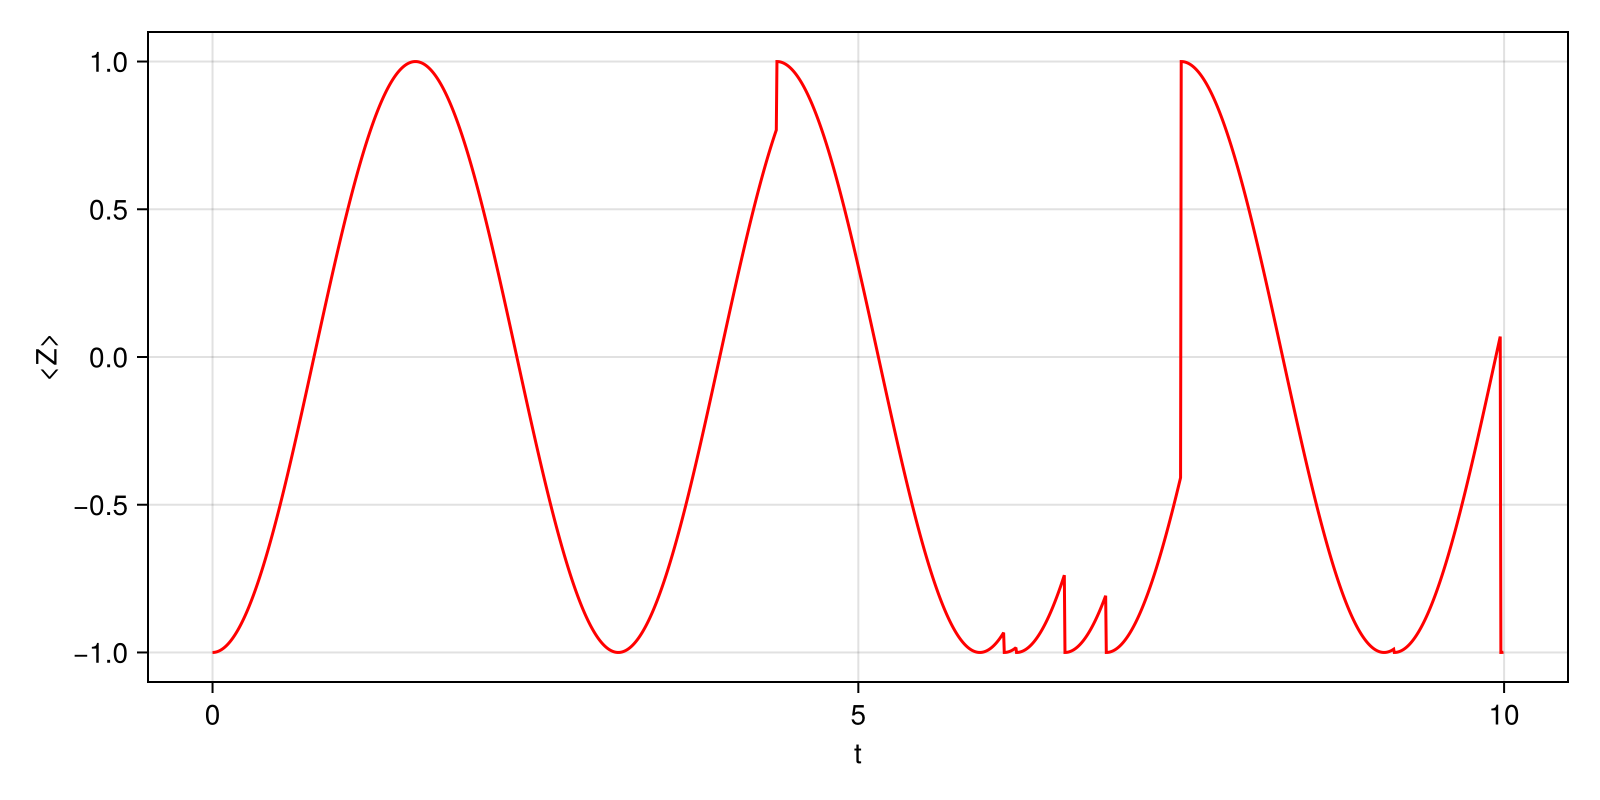

In [43]:
function projective_measurement(Z_avg, Z, psi)
    p_up = 0.5 * (1 + Z_avg)

    r = rand()

    if r < p_up
        psi += Z * psi
    else
        psi -= Z * psi
    end

    return psi / norm(psi)
end

function monitored_dynamics(H, gamma, dt, ntsteps, psi0)
    # Implement unitary dynamics iterspersed with projective measurements of Z
    Z = [1 0; 0 -1]
    Z_avg = zeros(ntsteps)

    psi = copy(psi0)

    U = exp(-im * H * dt)

    wait_time = 0.0
    r = rand()

    for tt in 1:ntsteps
        Z_avg[tt] = real(psi' * Z * psi)
        psi = U * psi

        wait_time += dt

        if exp(-gamma * wait_time) < r
            # Continuous check evaluated discretely
            psi = projective_measurement(Z_avg[tt], Z, psi)
            wait_time = 0.0
            r = rand()
        end
    end

    return Z_avg
end

psi0 = [0, 1]

Z_traj = monitored_dynamics(H, gamma, dt, ntsteps, psi0)

t = (0:ntsteps-1) .* dt

fig = Figure(size = (800, 400))
ax = Axis(fig[1, 1],
    xlabel = "t",
    ylabel = "<Z>",
    xgridvisible = true,
    ygridvisible = true
)

lines!(ax, t, Z_traj, color = :red)

fig

Quantum trajectories are not just a tool for simulating open dynamics, they assume physical meaning in terms of monitored evolution. In modern experiments, i's possible to generate monitoring protocols that realize specific stochastic Schrodinger equations.

Finally, let's consider the average dynamics for multiple values of $\gamma$.

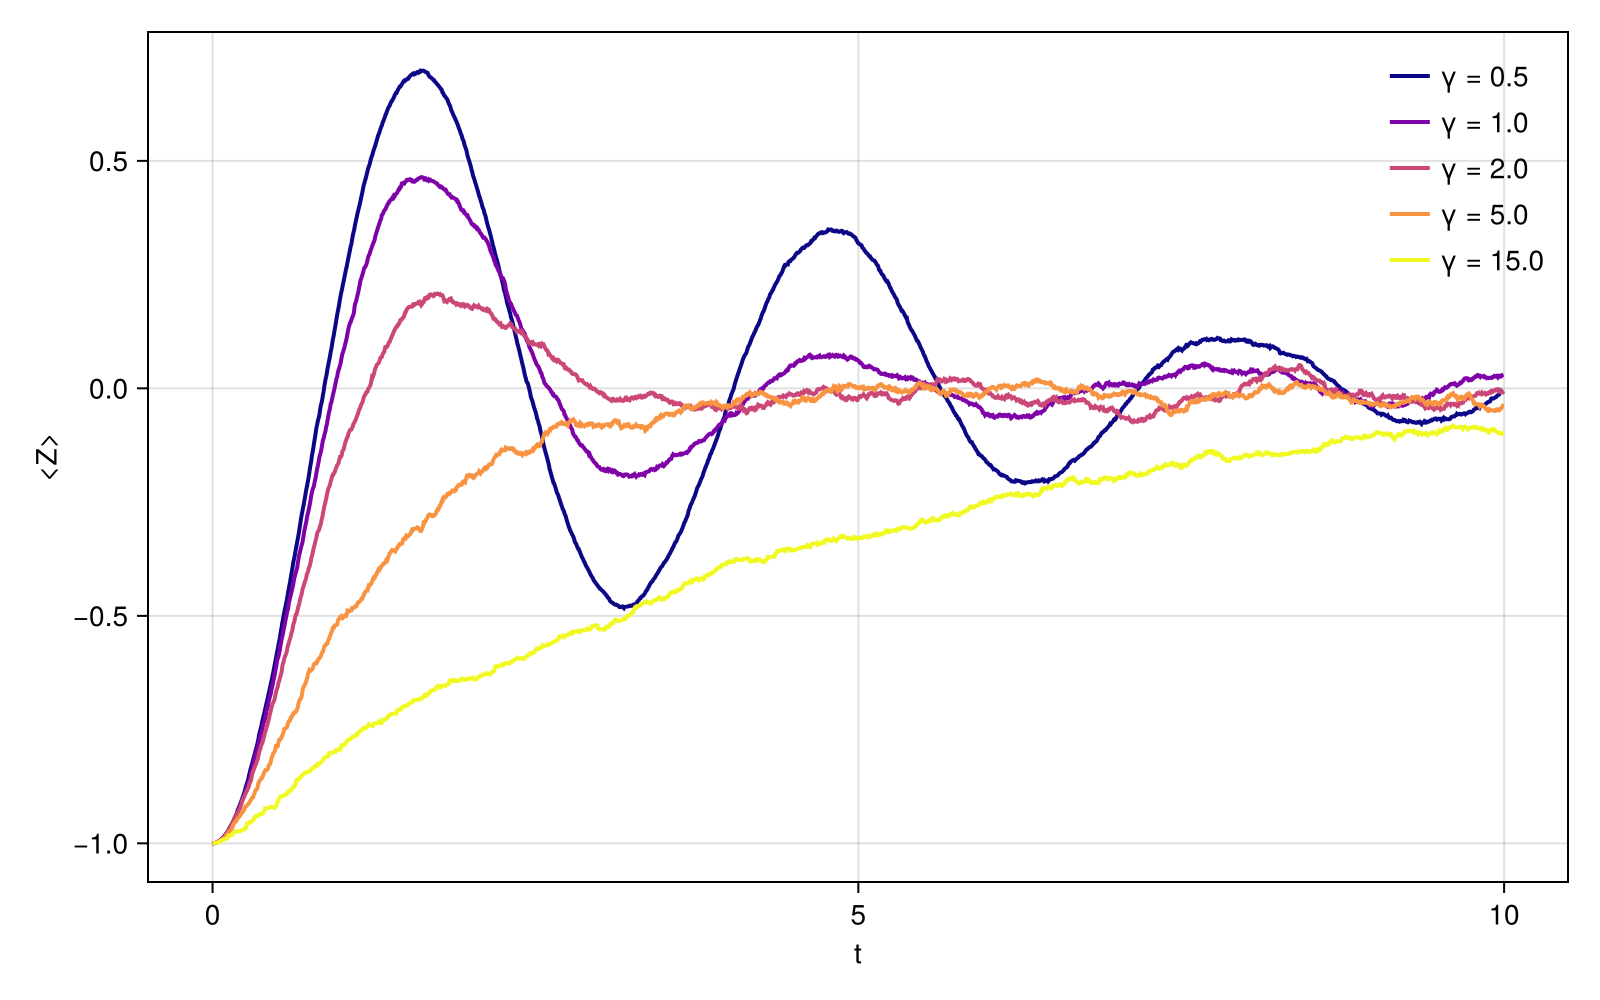

In [49]:
gammaList = [0.5, 1.0, 2.0, 5.0, 15.0]

fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1],
    xlabel = "t",
    ylabel = "<Z>",
    xgridvisible = true,
    ygridvisible = true
)

sample = 1000

colors = cgrad(:plasma, length(gammaList), categorical = true)

for (gg, gamma) in enumerate(gammaList)
    Z_proj = zeros(ntsteps)

    for ss in 1:sample
        Z_traj = monitored_dynamics(H, gamma, dt, ntsteps, psi0)
        Z_proj .+= Z_traj ./ sample
    end

    label_str = "γ = $(round(gamma, digits=1))"
    lines!(ax, t, Z_proj, color = colors[gg], label = label_str, linewidth = 2.0)
end

axislegend(ax, framevisible = false, position = :rt)

fig

Do you notice anything strange? Starting from small $\gamma$ and increasing it, the dynamics relaxes faster and faster, compatible with having a stronger dissipator. However, at larger rate values, the approach to the steady states slows down! This is known as the quantum Zeno effect: since the system is measured at very high frequency, the dynamics effectively freezes in an eigenstate of the measurement operator. As a consequence, the relaxation time to the steady state no longer scales as $\sim 1/\gamma$, but as $\sim \gamma/\omega^2$. This can be seen from the behavior of the spectral gap of the Lindbladian.

# Exercise: Entanglement in a two-qubit system with dissipation

Let us consider two qubits interacting with an Ising-like Hamiltonian
\begin{equation}
H = J \sigma_1^x\sigma_2^x + h(\sigma_1^z + \sigma_2^z).
\end{equation}
Suppose the first qubit is subject to dissipation induced by $L = \sigma_1^+$ with a rate $\gamma$.

Unravel the master equation using quantum jumps. What happens to the second qubit when a jump affects the first one?

We are then interested in evaluating the entanglement between the two qubits. This can be quantified using the entanglement entropy
\begin{equation}
S_1 = - Tr(\rho_1\log \rho_1),
\end{equation}
where $\rho_1 = Tr_2(|\psi\rangle\langle\psi|)$ is the reduced density matrix of the first qubit. If you are not too familiar with the entanglement entropy, you can instead compute the 2-Renyi entropy
\begin{equation}
S^{(2)}_1 = - \log Tr(\rho_1^2),
\end{equation}
so that you can avoid dealing with the logarithm of the reduced density matrix.

Compute entanglement entropy as a function of time for each trajectory, and average it over multiple random realizations. Then, implement a quantum state diffusion unraveling and do the same. Do the two results match? Why?